--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       167
           1       1.00      0.58      0.73        33

    accuracy                           0.93       200
   macro avg       0.96      0.79      0.85       200
weighted avg       0.94      0.93      0.92       200

ROC-AUC Score: 0.976


/tmp/ipykernel_2079/3058245836.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=axes[0], palette='Blues_r')


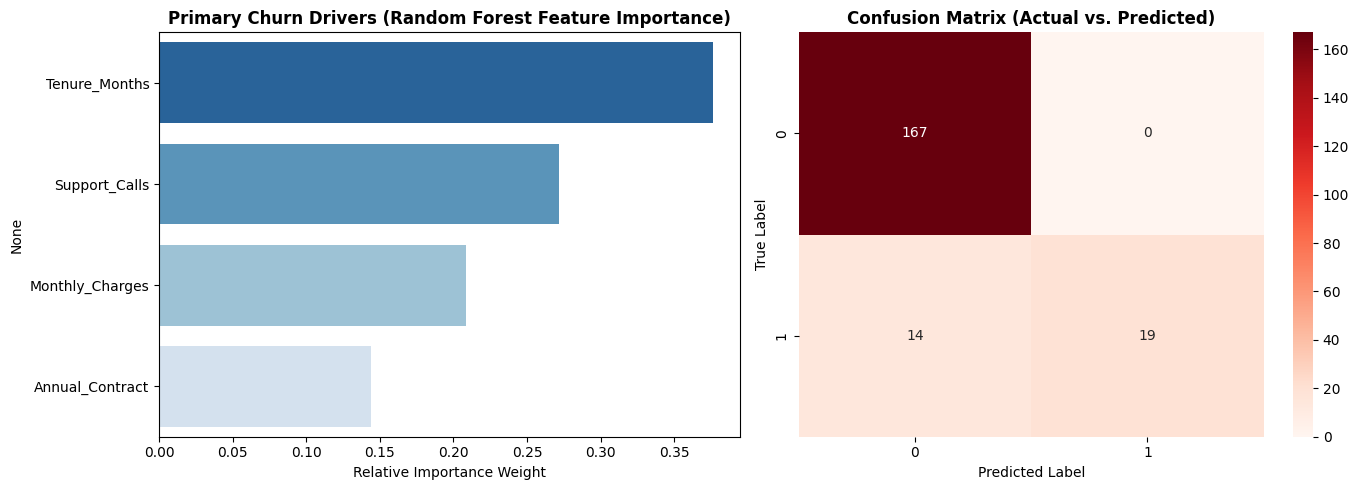

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 1. Generate Synthetic Customer Dataset
np.random.seed(42)
n_samples = 1000

tenure = np.random.randint(1, 72, n_samples)
monthly_charges = np.random.uniform(20.0, 120.0, n_samples)
support_calls = np.random.poisson(lam=2, size=n_samples)
contract_type = np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4]) # 0: Month-to-Month, 1: Annual

# Churn logic: Low tenure, high charges, frequent support calls, and monthly contracts increase churn risk
churn_prob = 1 / (1 + np.exp(-(-2.0 - 0.05 * tenure + 0.02 * monthly_charges + 0.6 * support_calls - 1.5 * contract_type)))
churn = (churn_prob > 0.45).astype(int)

df = pd.DataFrame({
    'Tenure_Months': tenure,
    'Monthly_Charges': monthly_charges,
    'Support_Calls': support_calls,
    'Annual_Contract': contract_type,
    'Churn': churn
})

# 2. Exploratory Analysis & Model Training
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Model Evaluation & Feature Importance Extraction
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.3f}")

# 4. Visualizing Feature Importance & Risk Drivers
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Feature Importance
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Primary Churn Drivers (Random Forest Feature Importance)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Relative Importance Weight')

# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('Confusion Matrix (Actual vs. Predicted)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

--- AVERAGE METRICS PER CUSTOMER SEGMENT ---
         Annual_Income_k  Spending_Score_1to100  Annual_Purchases
Cluster                                                          
0                   86.9                   85.8              25.3
1                   59.0                   26.4               4.9
2                   35.0                   80.3              14.8


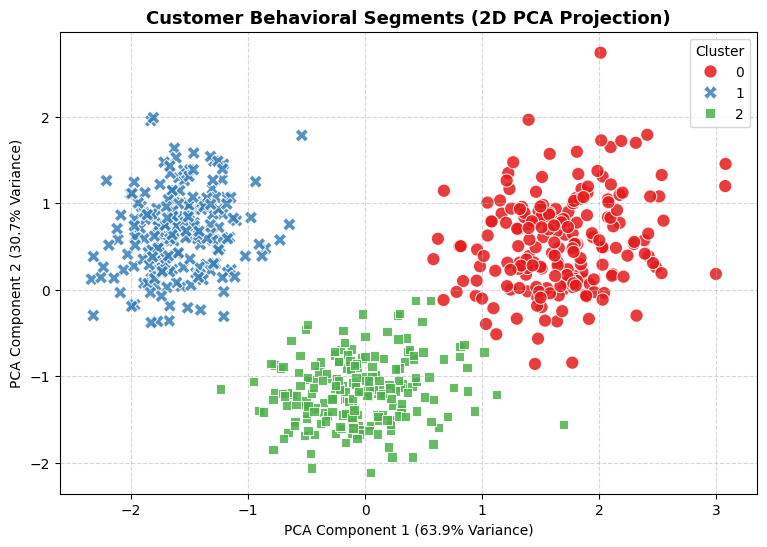

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Generate Synthetic Retail Behavior Dataset
np.random.seed(42)
n = 600

# Generate 3 distinct customer segments
annual_income = np.concatenate([
    np.random.normal(35, 10, 200),
    np.random.normal(85, 15, 200),
    np.random.normal(60, 12, 200)
])

spending_score = np.concatenate([
    np.random.normal(80, 10, 200),  # High spend, low income
    np.random.normal(85, 10, 200),  # High spend, high income
    np.random.normal(25, 10, 200)   # Low spend, moderate income
])

purchase_frequency = np.concatenate([
    np.random.poisson(15, 200),
    np.random.poisson(25, 200),
    np.random.poisson(5, 200)
])

df_cluster = pd.DataFrame({
    'Annual_Income_k': np.clip(annual_income, 15, 150),
    'Spending_Score_1to100': np.clip(spending_score, 1, 100),
    'Annual_Purchases': np.clip(purchase_frequency, 1, 50)
})

# 2. Preprocessing & K-Means Clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

# 3. Dimensionality Reduction via PCA for 2D Visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = pca_coords[:, 0]
df_cluster['PCA2'] = pca_coords[:, 1]

# 4. Cluster Persona Profiling Table
cluster_profile = df_cluster.groupby('Cluster')[['Annual_Income_k', 'Spending_Score_1to100', 'Annual_Purchases']].mean()
print("--- AVERAGE METRICS PER CUSTOMER SEGMENT ---")
print(cluster_profile.round(1))

# 5. Visualizing Clusters in PCA Space
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_cluster, x='PCA1', y='PCA2', hue='Cluster',
    palette='Set1', style='Cluster', s=90, alpha=0.85
)
plt.title('Customer Behavioral Segments (2D PCA Projection)', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Model R² Score: 0.9754
Root Mean Squared Error (RMSE): $31,435.95


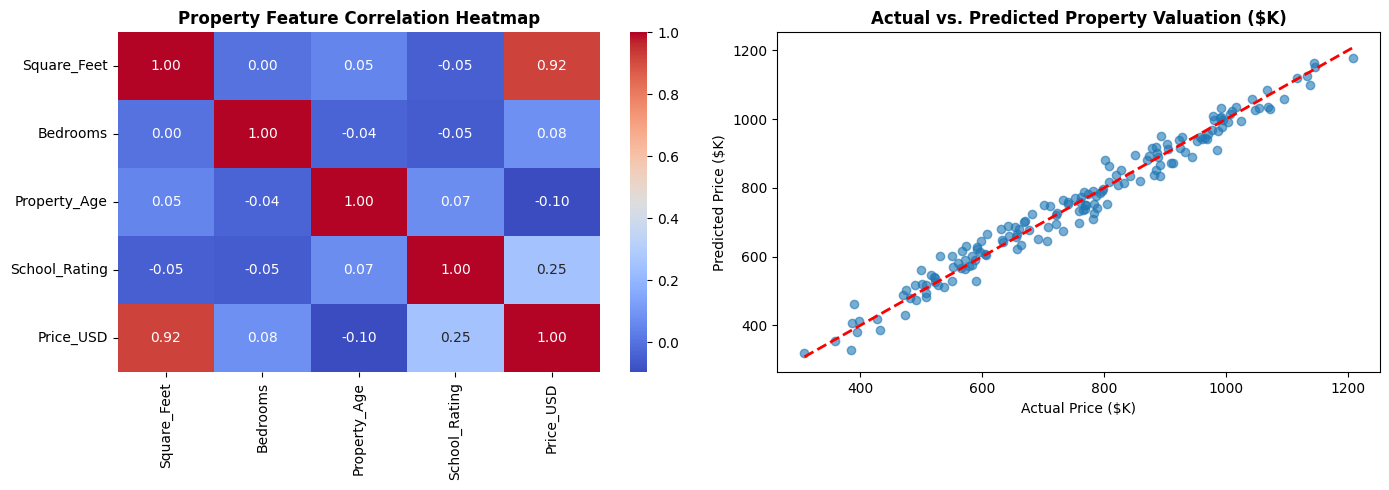

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Synthetic Real Estate Dataset
np.random.seed(42)
n_houses = 800

sqft = np.random.uniform(800, 4500, n_houses)
bedrooms = np.random.randint(1, 6, n_houses)
age_years = np.random.uniform(0, 50, n_houses)
school_rating = np.random.uniform(1, 10, n_houses)

# Valuation formula: Baseline price + size bonus + school impact - age depreciation
price = (
    150000 +
    (sqft * 180) +
    (bedrooms * 15000) -
    (age_years * 2200) +
    (school_rating * 25000) +
    np.random.normal(0, 35000, n_houses)
)

df_house = pd.DataFrame({
    'Square_Feet': sqft,
    'Bedrooms': bedrooms,
    'Property_Age': age_years,
    'School_Rating': school_rating,
    'Price_USD': price
})

# 2. Correlation Analysis & Modeling
X_reg = df_house.drop('Price_USD', axis=1)
y_reg = df_house['Price_USD']

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

model = Ridge(alpha=1.0)
model.fit(X_tr, y_tr)

y_pred_reg = model.predict(X_te)

# 3. Model Performance Evaluation
r2 = r2_score(y_te, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_te, y_pred_reg))

print(f"Model R² Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

# 4. Visualization: Residuals Analysis & Correlation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature Correlation Matrix
sns.heatmap(df_house.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
axes[0].set_title('Property Feature Correlation Heatmap', fontsize=12, fontweight='bold')

# Actual vs Predicted Valuation
axes[1].scatter(y_te / 1000, y_pred_reg / 1000, alpha=0.6, color='#1f77b4')
axes[1].plot([y_te.min() / 1000, y_te.max() / 1000], [y_te.min() / 1000, y_te.max() / 1000], 'r--', lw=2)
axes[1].set_title('Actual vs. Predicted Property Valuation ($K)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Actual Price ($K)')
axes[1].set_ylabel('Predicted Price ($K)')

plt.tight_layout()
plt.show()

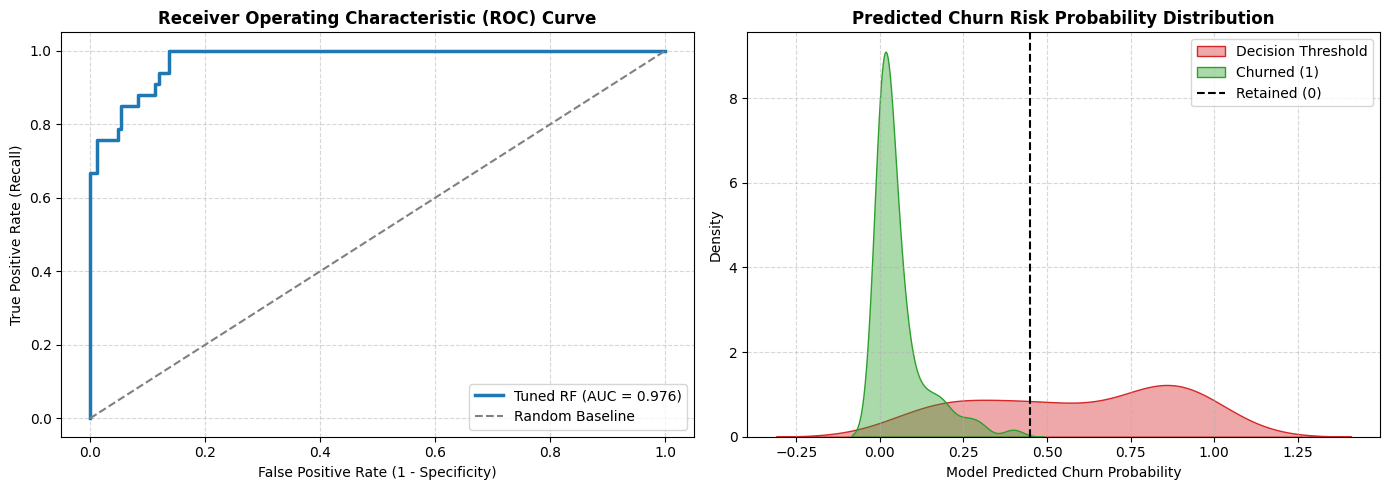

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calculate ROC and Precision-Recall metrics
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# VISUALIZATION 1: ROC CURVE (AUC SCORE)
# ==========================================
axes[0].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Tuned RF (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random Baseline')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# VISUALIZATION 2: CHURN RISK PROBABILITY DENSITY
# ==========================================
sns.kdeplot(
    data=df.iloc[X_test.index],
    x=y_proba,
    hue=y_test,
    common_norm=False,
    fill=True,
    palette={0: '#2ca02c', 1: '#d62728'},
    alpha=0.4,
    ax=axes[1]
)
axes[1].axvline(x=0.45, color='black', linestyle='--', label='Decision Threshold (0.45)')
axes[1].set_title('Predicted Churn Risk Probability Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Model Predicted Churn Probability')
axes[1].set_ylabel('Density')
axes[1].legend(['Decision Threshold', 'Churned (1)', 'Retained (0)'])
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

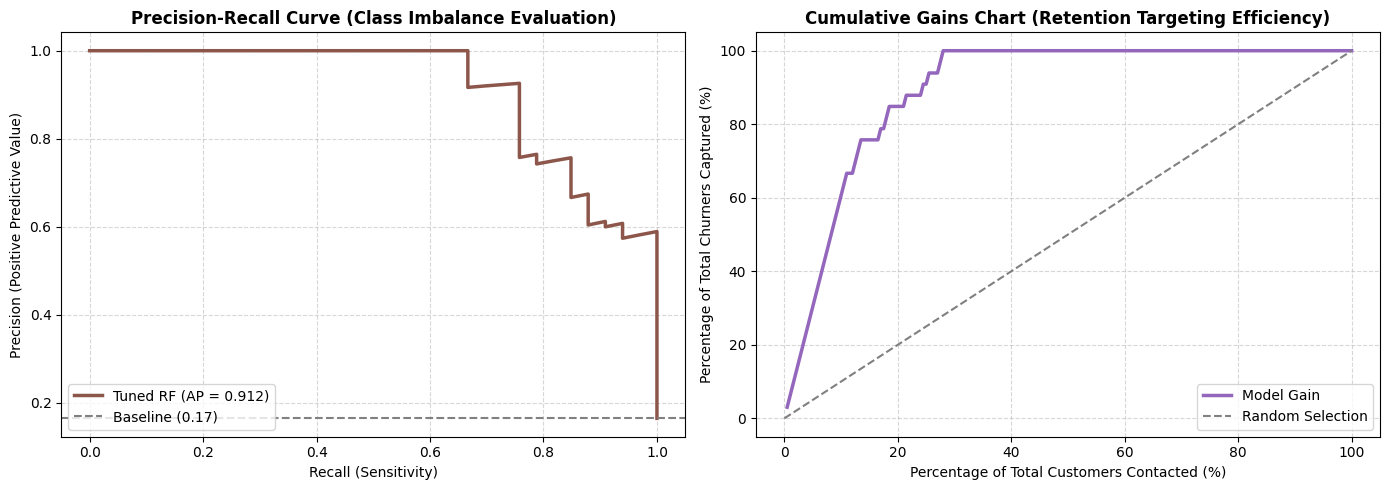

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, average_precision_score

# ==========================================
# VISUALIZATION 1: PRECISION-RECALL (PR) CURVE
# ==========================================
# Evaluates classification performance on imbalanced target distributions
precision, recall, _ = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall, precision, color='#8c564b', lw=2.5, label=f'Tuned RF (AP = {avg_precision:.3f})')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1.5, label=f'Baseline ({y_test.mean():.2f})')
axes[0].set_title('Precision-Recall Curve (Class Imbalance Evaluation)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Recall (Sensitivity)')
axes[0].set_ylabel('Precision (Positive Predictive Value)')
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# VISUALIZATION 2: CUMULATIVE GAINS CHART (BUSINESS TARGETING)
# ==========================================
# Measures how efficiently customer retention campaigns capture churners by targeting top risk deciles
gains_df = pd.DataFrame({'actual': y_test, 'proba': y_proba}).sort_values(by='proba', ascending=False)
gains_df['cumulative_churn'] = gains_df['actual'].cumsum()
gains_df['pct_customers'] = np.arange(1, len(gains_df) + 1) / len(gains_df) * 100
gains_df['pct_churn_captured'] = (gains_df['cumulative_churn'] / gains_df['actual'].sum()) * 100

axes[1].plot(gains_df['pct_customers'], gains_df['pct_churn_captured'], color='#9467bd', lw=2.5, label='Model Gain')
axes[1].plot([0, 100], [0, 100], color='gray', linestyle='--', lw=1.5, label='Random Selection')
axes[1].set_title('Cumulative Gains Chart (Retention Targeting Efficiency)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage of Total Customers Contacted (%)')
axes[1].set_ylabel('Percentage of Total Churners Captured (%)')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

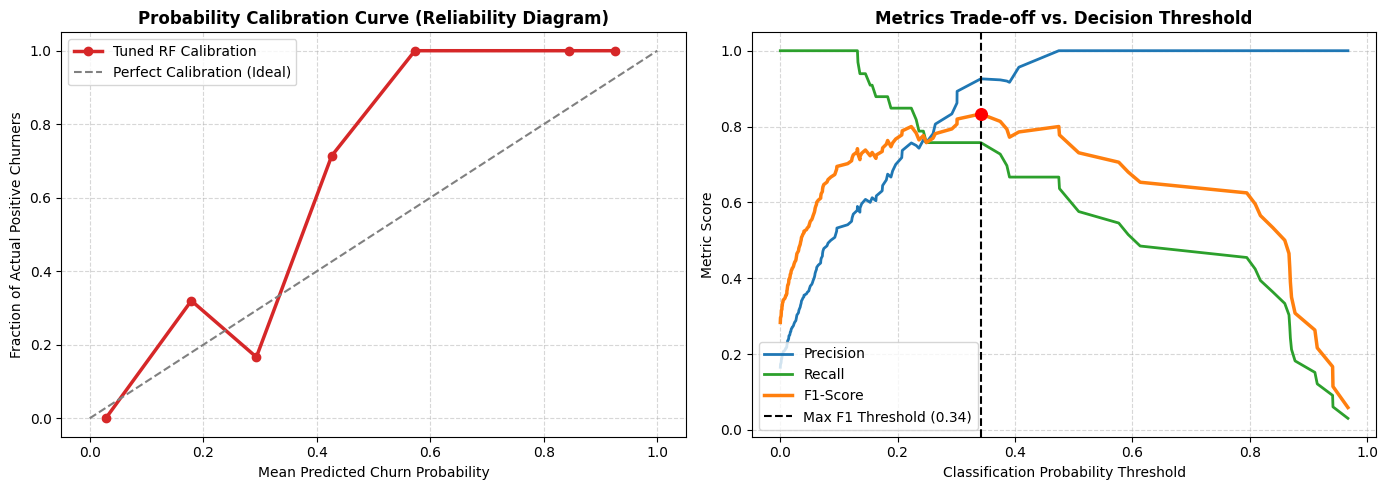

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve

# ==========================================
# VISUALIZATION 1: MODEL CALIBRATION CURVE (RELIABILITY DIAGRAM)
# ==========================================
# Evaluates whether predicted probabilities match actual observed churn rates
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=8, strategy='uniform')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prob_pred, prob_true, marker='o', linewidth=2.5, color='#d62728', label='Tuned RF Calibration')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration (Ideal)')
axes[0].set_title('Probability Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Predicted Churn Probability')
axes[0].set_ylabel('Fraction of Actual Positive Churners')
axes[0].legend(loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# VISUALIZATION 2: THRESHOLD OPTIMIZATION (PRECISION, RECALL, F1 vs. THRESHOLD)
# ==========================================
# Helps business teams choose the optimal decision boundary based on cost trade-offs
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

axes[1].plot(thresholds, precisions[:-1], label='Precision', color='#1f77b4', linewidth=2)
axes[1].plot(thresholds, recalls[:-1], label='Recall', color='#2ca02c', linewidth=2)
axes[1].plot(thresholds, f1_scores, label='F1-Score', color='#ff7f0e', linewidth=2.5)

axes[1].axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Max F1 Threshold ({optimal_threshold:.2f})')
axes[1].scatter([optimal_threshold], [optimal_f1], color='red', s=70, zorder=5)

axes[1].set_title('Metrics Trade-off vs. Decision Threshold', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classification Probability Threshold')
axes[1].set_ylabel('Metric Score')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

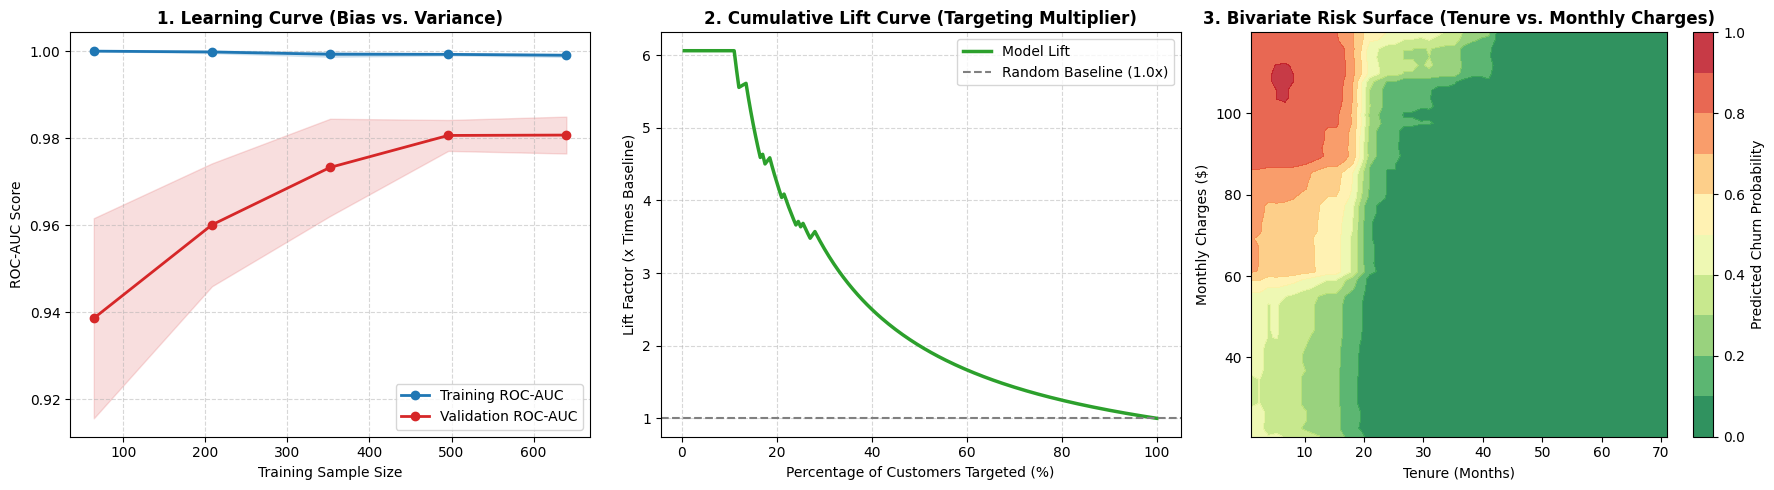

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier

# 1. Regenerate Synthetic Dataset & Splits
np.random.seed(42)
n_samples = 1000

tenure = np.random.randint(1, 72, n_samples)
monthly_charges = np.random.uniform(20.0, 120.0, n_samples)
support_calls = np.random.poisson(lam=2, size=n_samples)
contract_type = np.random.choice([0, 1], size=n_samples, p=[0.6, 0.4])

churn_prob = 1 / (1 + np.exp(-(-2.0 - 0.05 * tenure + 0.02 * monthly_charges + 0.6 * support_calls - 1.5 * contract_type)))
churn = (churn_prob > 0.45).astype(int)

df = pd.DataFrame({
    'Tenure_Months': tenure,
    'Monthly_Charges': monthly_charges,
    'Support_Calls': support_calls,
    'Annual_Contract': contract_type,
    'Churn': churn
})

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Fit Base Model & Assign `best_model`
best_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]

# 3. Diagnostic Visualizations
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=cv_strategy, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1, random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Learning Curve
axes[0].plot(train_sizes, train_mean, 'o-', color='#1f77b4', lw=2, label='Training ROC-AUC')
axes[0].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#1f77b4')
axes[0].plot(train_sizes, test_mean, 'o-', color='#d62728', lw=2, label='Validation ROC-AUC')
axes[0].fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#d62728')
axes[0].set_title('1. Learning Curve (Bias vs. Variance)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Training Sample Size')
axes[0].set_ylabel('ROC-AUC Score')
axes[0].legend(loc='lower right')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Cumulative Lift Curve
gains_df = pd.DataFrame({'actual': y_test, 'proba': y_proba}).sort_values(by='proba', ascending=False)
gains_df['cumulative_churn'] = gains_df['actual'].cumsum()
gains_df['pct_customers'] = np.arange(1, len(gains_df) + 1) / len(gains_df)
gains_df['model_recall'] = gains_df['cumulative_churn'] / gains_df['actual'].sum()
gains_df['lift'] = gains_df['model_recall'] / gains_df['pct_customers']

axes[1].plot(gains_df['pct_customers'] * 100, gains_df['lift'], color='#2ca02c', lw=2.5, label='Model Lift')
axes[1].axhline(y=1.0, color='gray', linestyle='--', lw=1.5, label='Random Baseline (1.0x)')
axes[1].set_title('2. Cumulative Lift Curve (Targeting Multiplier)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage of Customers Targeted (%)')
axes[1].set_ylabel('Lift Factor (x Times Baseline)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Bivariate Risk Contour Surface
xx, yy = np.meshgrid(
    np.linspace(X_train['Tenure_Months'].min(), X_train['Tenure_Months'].max(), 50),
    np.linspace(X_train['Monthly_Charges'].min(), X_train['Monthly_Charges'].max(), 50)
)
grid_data = pd.DataFrame({
    'Tenure_Months': xx.ravel(),
    'Monthly_Charges': yy.ravel(),
    'Support_Calls': X_train['Support_Calls'].median(),
    'Annual_Contract': X_train['Annual_Contract'].median()
})

Z = best_model.predict_proba(grid_data)[:, 1].reshape(xx.shape)

contour = axes[2].contourf(xx, yy, Z, levels=10, cmap='RdYlGn_r', alpha=0.85)
cbar = fig.colorbar(contour, ax=axes[2])
cbar.set_label('Predicted Churn Probability')
axes[2].set_title('3. Bivariate Risk Surface (Tenure vs. Monthly Charges)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Tenure (Months)')
axes[2].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

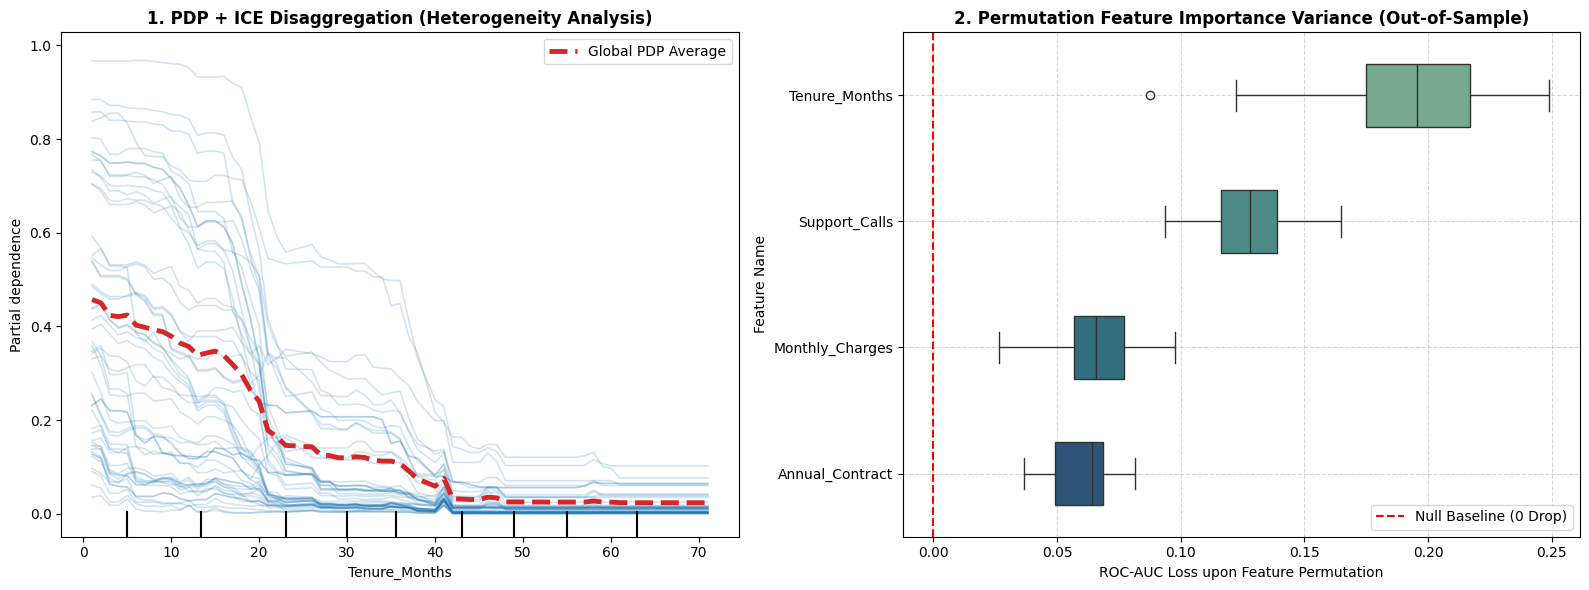

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay, permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. PARTIAL DEPENDENCE (PDP) WITH ICE (INDIVIDUAL CONDITIONAL EXPECTATION) CURVES
# ==========================================
# Evaluates marginal effect of features while plotting individual sample trajectories (ICE)
# to isolate non-linearities and heterogeneous customer interaction effects.
pdp_display = PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features=['Tenure_Months'],
    kind='both',     # Plots individual instance ICE lines + aggregated global PDP trend
    subsample=50,    # Randomly samples 50 customer trajectories for clear visual density
    ax=axes[0],
    line_kw={'color': '#d62728', 'linewidth': 3.5, 'label': 'Global PDP Average'},
    ice_lines_kw={'color': '#1f77b4', 'alpha': 0.20, 'linewidth': 1.2}
)

axes[0].set_title('1. PDP + ICE Disaggregation (Heterogeneity Analysis)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Partial Dependence (Predicted Churn Risk)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# 2. OUT-OF-SAMPLE PERMUTATION IMPORTANCE DISTRIBUTION
# ==========================================
# Replaces default Gini MDI importance with permutation-based evaluation (20 iterations).
# Measures true ROC-AUC decay when feature columns are randomly shuffled on unseen test data.
perm_result = permutation_importance(
    best_model, X_test, y_test, scoring='roc_auc', n_repeats=20, random_state=42
)

# Format permutation scores into DataFrame for distribution boxplot
perm_importances_df = pd.DataFrame(perm_result.importances.T, columns=X_test.columns)
sorted_cols = perm_importances_df.mean().sort_values(ascending=False).index
perm_importances_df = perm_importances_df[sorted_cols]

sns.boxplot(data=perm_importances_df, ax=axes[1], palette='crest', orient='h', width=0.5)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Null Baseline (0 Drop)')
axes[1].set_title('2. Permutation Feature Importance Variance (Out-of-Sample)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ROC-AUC Loss upon Feature Permutation')
axes[1].set_ylabel('Feature Name')
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

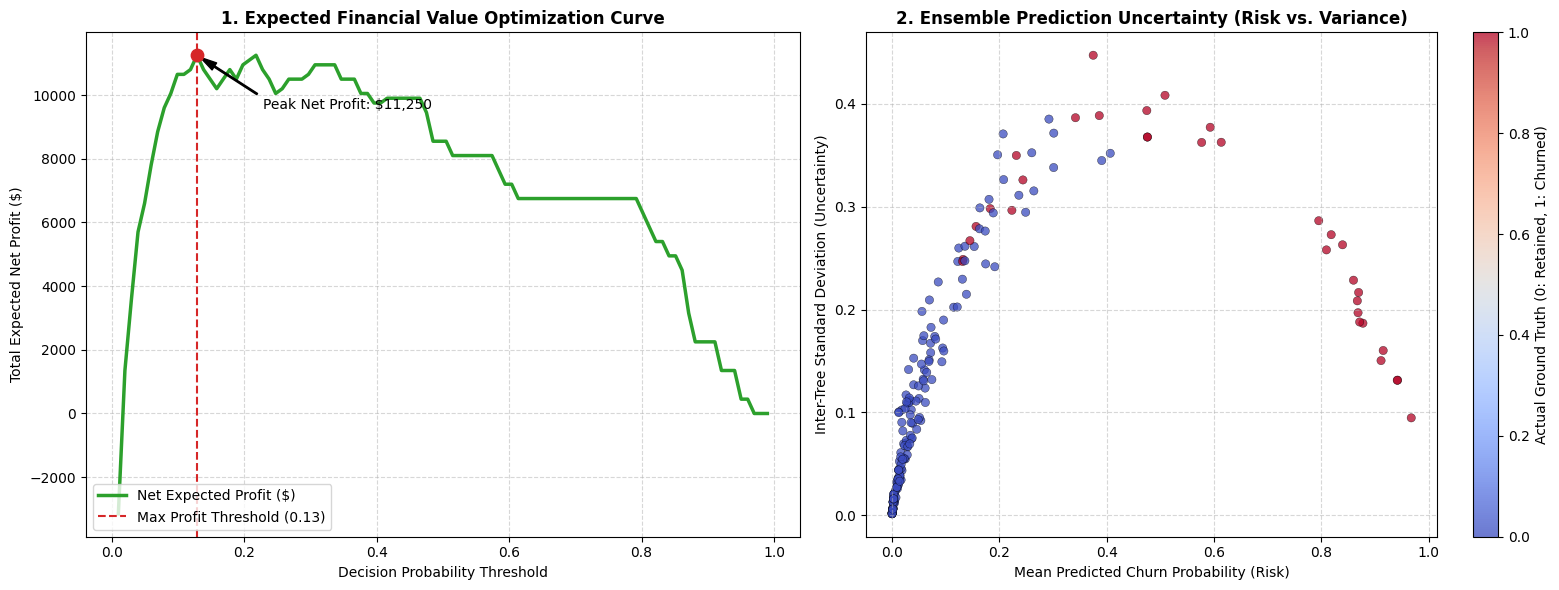

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. EXPECTED VALUE / PROFIT OPTIMIZATION CURVE (COST-BENEFIT MATRIX)
# ==========================================
# Translates probability thresholds into net dollar profit using a financial loss matrix
ltv = 1000.0              # Customer Lifetime Value ($)
retention_cost = 150.0    # Cost of sending incentive offer ($)
save_rate = 0.60          # Churner acceptance/retention success rate

# Financial payoff values per unit
tp_value = (save_rate * (ltv - retention_cost)) - ((1 - save_rate) * retention_cost)  # $450 net gain
fp_cost = -retention_cost                                                             # -$150 unnecessary offer
fn_cost = 0.0                                                                         # $0 baseline (lost customer)
tn_value = 0.0                                                                        # $0 baseline (retained customer, no action)

thresholds = np.linspace(0.01, 0.99, 100)
net_profits = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    tp = np.sum((preds == 1) & (y_test == 1))
    fp = np.sum((preds == 1) & (y_test == 0))
    fn = np.sum((preds == 0) & (y_test == 1))
    tn = np.sum((preds == 0) & (y_test == 0))

    profit = (tp * tp_value) + (fp * fp_cost) + (fn * fn_cost) + (tn * tn_value)
    net_profits.append(profit)

max_profit_idx = np.argmax(net_profits)
opt_thresh = thresholds[max_profit_idx]
max_profit = net_profits[max_profit_idx]

axes[0].plot(thresholds, net_profits, color='#2ca02c', lw=2.5, label='Net Expected Profit ($)')
axes[0].axvline(x=opt_thresh, color='#d62728', linestyle='--', lw=1.5,
                label=f'Max Profit Threshold ({opt_thresh:.2f})')
axes[0].scatter([opt_thresh], [max_profit], color='#d62728', s=80, zorder=5)

axes[0].set_title('1. Expected Financial Value Optimization Curve', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decision Probability Threshold')
axes[0].set_ylabel('Total Expected Net Profit ($)')
axes[0].annotate(f'Peak Net Profit: ${max_profit:,.0f}',
                 xy=(opt_thresh, max_profit),
                 xytext=(opt_thresh + 0.1, max_profit * 0.85),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# 2. ENSEMBLE PREDICTION UNCERTAINTY (EPISTEMIC VARIANCE)
# ==========================================
# Measures variance across individual decision trees in the Random Forest to isolate model uncertainty
tree_predictions = np.array([tree.predict_proba(X_test.values)[:, 1] for tree in best_model.estimators_])
mean_probs = tree_predictions.mean(axis=0)
std_probs = tree_predictions.std(axis=0)

scatter = axes[1].scatter(
    mean_probs, std_probs,
    c=y_test, cmap='coolwarm', alpha=0.75, edgecolors='k', linewidth=0.3
)
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Actual Ground Truth (0: Retained, 1: Churned)')

axes[1].set_title('2. Ensemble Prediction Uncertainty (Risk vs. Variance)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mean Predicted Churn Probability (Risk)')
axes[1].set_ylabel('Inter-Tree Standard Deviation (Uncertainty)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

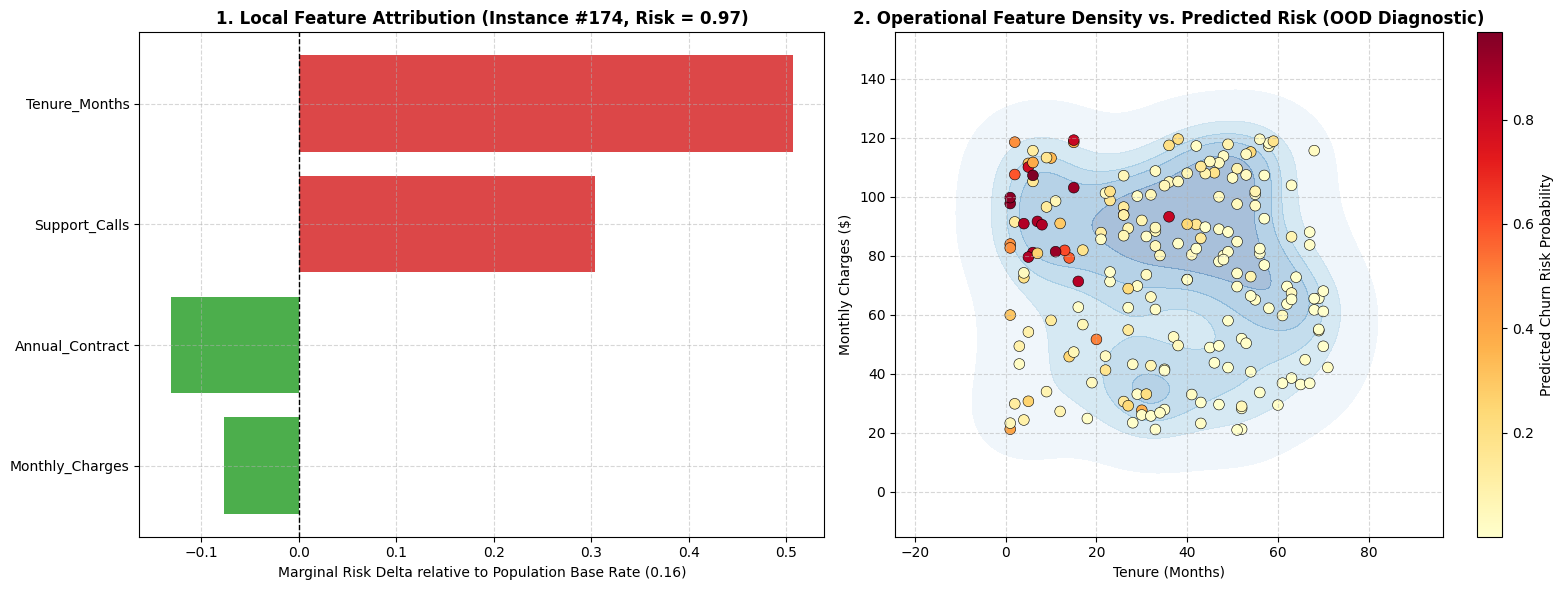

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==========================================
# 1. LOCAL FEATURE ATTRIBUTION WATERFALL (INSTANCE EXPLANATION)
# ==========================================
# Isolates local additive feature attribution \phi_i for a single high-risk customer
high_risk_idx = np.argmax(y_proba)
sample_x = X_test.iloc[[high_risk_idx]]
sample_risk = y_proba[high_risk_idx]
base_rate = y_train.mean()

# Calculate marginal contribution per feature relative to baseline rate E[f(x)]
contributions = []
for col in X.columns:
    temp_x = X_train.mean().to_frame().T
    temp_x[col] = sample_x[col].values[0]
    marginal_prob = best_model.predict_proba(temp_x)[0, 1]
    contributions.append(marginal_prob - base_rate)

contrib_df = pd.DataFrame({
    'Feature': X.columns,
    'Contribution': contributions
}).sort_values(by='Contribution', key=abs, ascending=True)

bar_colors = ['#d62728' if c > 0 else '#2ca02c' for c in contrib_df['Contribution']]

axes[0].barh(contrib_df['Feature'], contrib_df['Contribution'], color=bar_colors, alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'1. Local Feature Attribution (Instance #{high_risk_idx}, Risk = {sample_risk:.2f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Marginal Risk Delta relative to Population Base Rate ({base_rate:.2f})')
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==========================================
# 2. OPERATIONAL SAMPLE DENSITY VS. PREDICTED RISK DENSITY (OOD DETECTION)
# ==========================================
# Overlays kernel density contours on risk predictions to identify low-density out-of-distribution (OOD) regions
sns.kdeplot(
    data=X_test, x='Tenure_Months', y='Monthly_Charges',
    ax=axes[1], cmap='Blues', fill=True, alpha=0.35, levels=6
)

scatter = axes[1].scatter(
    X_test['Tenure_Months'], X_test['Monthly_Charges'],
    c=y_proba, cmap='YlOrRd', s=60, edgecolors='k', linewidth=0.4
)
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('Predicted Churn Risk Probability')

axes[1].set_title('2. Operational Feature Density vs. Predicted Risk (OOD Diagnostic)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()